![NVIDIA Logo](images/nvidia.png)

# Exercise: Multi-Stage PCAP Analysis

For this exercise you will be continuing to work with the PCAP data, this time creating multiple custom stages that can be used together in a linear pipeline in service of an analysis pipeline.

---

## Load PCAP Data

In [1]:
import cudf

In [2]:
input_file = 'data/pcap_dump.jsonlines'

In [3]:
pcap = cudf.read_json(input_file, lines=True)

---

## PCAP Filter Function

`filter_pcap_data` filters PCAP data based on IP address, port, or protocol.

In [4]:
def filter_pcap_data(
    df: cudf.DataFrame, 
    filter_ip: str = None, 
    filter_port: str = None, 
    filter_protocol: str = None
) -> cudf.DataFrame:
    """
    Filters PCAP data based on IP address, port, or protocol.

    Args:
        df (cudf.DataFrame): The input network traffic data.
        filter_ip (str, optional): IP address to filter packets (either src_ip or dest_ip).
        filter_port (str, optional): Port to filter packets (either src_port or dest_port).
        filter_protocol (str, optional): Protocol number to filter packets (e.g., "6" for TCP).

    Returns:
        cudf.DataFrame: Filtered data.
    """
    df["data_len"] = df["data_len"].astype("int32")  # Ensure numeric type

    if filter_ip:
        df = df[(df["src_ip"] == filter_ip) | (df["dest_ip"] == filter_ip)]
    
    if filter_port:
        df = df[(df["src_port"] == filter_port) | (df["dest_port"] == filter_port)]
    
    if filter_protocol:
        df = df[df["protocol"] == filter_protocol]

    return df

In [5]:
filtered_pcap = filter_pcap_data(pcap, filter_ip="10.100.8.98", filter_protocol="6")

In [6]:
filtered_pcap

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
0,1617810893485061,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28782,6443,16
1,1617810893525610,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,28782,16
2,1617810893640893,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,17
3,1617810893682471,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,69.192.193.45,10.100.8.98,80,49192,17
4,1617810893682486,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,16
...,...,...,...,...,...,...,...,...,...,...,...,...
537236,1617869019150167,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28762,6443,16
537237,1617869020210012,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28762,6443,16
537238,1617869021104938,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,40377,6443,16
537239,1617869021105132,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,40377,16


---

## Aggregate Packet Counts per Source IP

`aggregate_packets_per_source` aggregates packet counts per source IP.

In [7]:
def aggregate_packets_per_source(df: cudf.DataFrame) -> cudf.DataFrame:
    """
    Aggregates packet counts per source IP.

    Args:
        df (cudf.DataFrame): The filtered PCAP data.

    Returns:
        cudf.DataFrame: Source IPs with packet counts.
    """
    aggregated_df = (
        df.groupby("src_ip")
        .agg({"timestamp": "count"})
        .reset_index()
        .rename(columns={"timestamp": "packet_count"})
    )

    return aggregated_df

In [8]:
aggregated = aggregate_packets_per_source(filtered_pcap)

In [9]:
aggregated

,src_ip,packet_count
0,10.100.4.5,9738
1,10.100.3.10,9733
2,10.100.8.64,26157
3,169.254.169.254,147449
4,128.220.192.230,17
5,74.208.253.126,4
6,128.220.159.226,4
7,10.100.8.98,282978
8,151.101.54.167,5
9,10.100.1.237,59577


---

## Identify High-Volume Senders

`identify_high_volume_senders` identifies source IPs that sent more than a specified number of packets.

In [10]:
def identify_high_volume_senders(df: cudf.DataFrame, threshold: int = 100) -> cudf.DataFrame:
    """
    Identifies source IPs that sent more than a specified number of packets.

    Args:
        df (cudf.DataFrame): The source IP packet counts.
        threshold (int): The minimum number of packets to be considered high volume.

    Returns:
        cudf.DataFrame: A filtered DataFrame with only high-volume senders.
    """
    high_volume_df = df[df["packet_count"] > threshold]

    return high_volume_df

In [11]:
identify_high_volume_senders(aggregated)

,src_ip,packet_count
0,10.100.4.5,9738
1,10.100.3.10,9733
2,10.100.8.64,26157
3,169.254.169.254,147449
7,10.100.8.98,282978
9,10.100.1.237,59577
13,145.239.0.106,1518


---

## Full Pipeline

Here we utilize all 3 functions to filter specific traffic, aggregate packet counts and identify high-volume sources.

In [12]:
# Step 1: Filter packets (e.g., TCP traffic from a specific IP)
filtered_df = filter_pcap_data(pcap, filter_ip="10.100.8.98", filter_protocol="6")

# Step 2: Aggregate packet counts per source IP
aggregated_df = aggregate_packets_per_source(filtered_df)

# Step 3: Identify high-volume senders (e.g., more than 10 packets)
high_volume_df = identify_high_volume_senders(aggregated_df, threshold=10000)

In [13]:
high_volume_df

,src_ip,packet_count
2,10.100.8.64,26157
3,169.254.169.254,147449
7,10.100.8.98,282978
9,10.100.1.237,59577


---

## Exercise Objective

Create 3 custom stages, each capable of performing the work of one of the above helper functions. Be sure that the stages are parameterized when appropriate to enable their flexible reuse.

After creating the 3 custom stages, construct a pipeline that utilizes all three of them in serial order.

---

## Imports

You will likely need to use the following imports in your work.

In [14]:
import typing
import logging

from IPython.display import Image
import cudf

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.messages import MessageMeta

from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.cli.register_stage import register_stage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
from mrc.core import operators as ops

---

## Your Work Here

Build and run your pipeline in the space provided below. By all means feel free to create additional code cells for your work, which you can do by clicking the `+` button in the Jupyter menu bar at the top of this notebook.

If you get stuck, a solution is provided below, which you view by expanding the *Solution* section below.

In [15]:
@register_stage("filter-pcap")
class FilterPcap(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    def __init__(self, c: Config, ip: str="", port: str="", protocol: str=""):
        super().__init__(c)
        self._ip = ip
        self._port = port
        self._protocol = protocol
        
    @property
    def name(self) -> str:
        return "filter-pcap"
    def accepted_types(self) -> tuple:
        return (MessageMeta, )
    def supports_cpp_node(self) -> bool:
        return False
    def on_data(self, message: MessageMeta) -> MessageMeta:
        df = message.copy_dataframe()
        df = filter_pcap_data(df, self._ip, self._port, self._protocol)
        return MessageMeta(df)
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

In [23]:
%set_env PYTHONENCODING=UTF-8
@register_stage("aggre")
class AgreePcap(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    # def __init__(self, c: Config, ip: str="", port: str="", protocol: str=""):
    #     super().__init__(c)
    #     self._ip = ip
    #     self._port = port
    #     self._protocol = protocol
        
    @property
    def name(self) -> str:
        return "aggre"
    def accepted_types(self) -> tuple:
        return (MessageMeta, )
    def supports_cpp_node(self) -> bool:
        return False
    def on_data(self, message: MessageMeta) -> MessageMeta:
        df = message.copy_dataframe()
        df = aggregate_packets_per_source(df)
        return MessageMeta(df)
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

env: PYTHONENCODING=UTF-8


In [31]:
@register_stage("identi")
class Identi(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    def __init__(self, c: Config, ip: str="", port: str="", protocol: str=""):
        super().__init__(c)
        self._ip = ip
        self._port = port
        self._protocol = protocol
        
    @property
    def name(self) -> str:
        return "identi"
    def accepted_types(self) -> tuple:
        return (MessageMeta, )
    def supports_cpp_node(self) -> bool:
        return False
    def on_data(self, message: MessageMeta) -> MessageMeta:
        df = message.copy_dataframe()
        # df = filter_pcap_data(df, self._ip, self._port, self._protocol)
        df = identify_high_volume_senders(df, threshold=self._threshold)
        return MessageMeta(df)
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

In [32]:
config = Config()
pipeline = LinearPipeline(config)

In [33]:
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

pipeline.add_stage(FilterPcap(config, port="80"))
pipeline.add_stage(AgreePcap(config))
pipeline.add_stage(IdentifyHighVolume(config, threshold=1000))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.build()

NameError: name 'IdentifyHighVolume' is not defined

In [26]:
viz_file = './pipeline_visualizations/mutli_stage_pcap.png'
pipeline.visualize(viz_file)

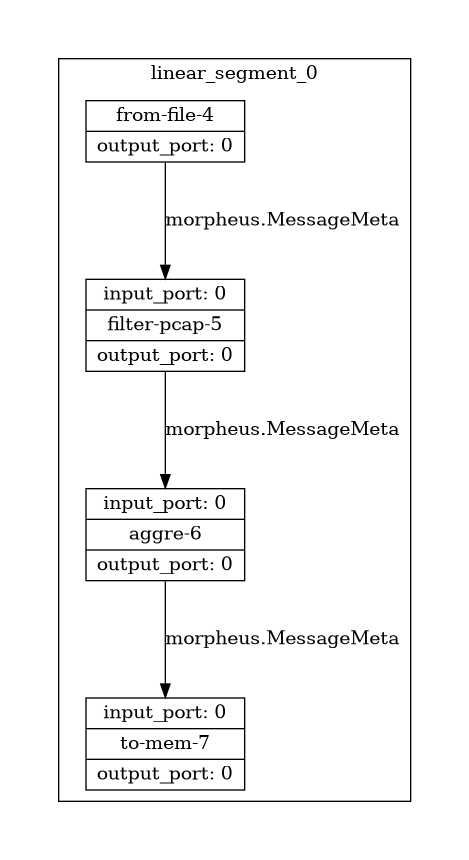

In [27]:
Image(filename=viz_file)

In [28]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250923 03:24:46.472739 140128209057600 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-4; FileSourceStage(filename=data/pcap_dump.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <filter-pcap-5; FilterPcap(ip=, port=80, protocol=)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <aggre-6; AgreePcap()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-7; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [29]:
await pipeline.run_async()

In [30]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,src_ip,packet_count
0,151.101.54.167,5
1,104.18.15.213,4
2,52.202.129.21,4
3,128.220.192.230,17
4,169.254.169.254,147449
5,128.220.159.226,4
6,156.40.212.153,4
7,74.208.253.126,4
8,69.192.193.45,44
9,151.101.54.137,5


---

## Solution

### Filter PCAP Data Custom Stage

In [ ]:
@register_stage("filter-pcap-data")
class FilterPcapData(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 filter_ip: str = None,
                 filter_port: str = None,
                 filter_protocol: str = None
                ):
        super().__init__(config)
        
        self._filter_ip = filter_ip
        self._filter_port = filter_port
        self._filter_protocol = filter_protocol

    @property
    def name(self) -> str:
        return "filter-pcap-data"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        df = message.copy_dataframe()
        results = filter_pcap_data(
            df,
            filter_ip=self._filter_ip,
            filter_port=self._filter_port,
            filter_protocol=self._filter_protocol
        )
        
        return MessageMeta(results)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node
#     1. FileSource -> FilterPcap -> InMemory
#     2. FileSource -> FilterPcap -> Aggregate -> InMemory 
#     3. FileSource -> FilterPcap -> Aggregate -> Identi -> InMemory

### Aggregate Packets Custom Stage

In [ ]:
@register_stage("agg-packets")
class AggPackets(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):

    @property
    def name(self) -> str:
        return "agg-packets"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        df = message.copy_dataframe()
        results = aggregate_packets_per_source(df)
        
        return MessageMeta(results)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

### Identify High Volume Custom Stage

In [ ]:
@register_stage("identify-high-volume")
class IdentifyHighVolume(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 threshold: int = 100
                ):
        super().__init__(config)
        
        self._threshold = threshold

    @property
    def name(self) -> str:
        return "identify-high-volume"

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        df = message.copy_dataframe()
        results = identify_high_volume_senders(
            df,
            threshold=self._threshold
        )
        
        return MessageMeta(results)

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

### Build the Pipeline

In [ ]:
config = Config()

In [ ]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

pipeline.add_stage(FilterPcapData(config, filter_ip="10.100.8.98", filter_protocol="6"))
pipeline.add_stage(AggPackets(config))
pipeline.add_stage(IdentifyHighVolume(config, threshold=1000))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [ ]:
pipeline.build()

In [ ]:
viz_file = './pipeline_visualizations/mutli_stage_pcap.png'
pipeline.visualize(viz_file)

In [ ]:
Image(filename=viz_file)

### Run the Pipeline

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

In [ ]:
messages = in_mem_sink.get_messages()
messages[0].get_data()